practict

In [1]:
def case2_trans(close,stockid):
    trans = 0
    trans_bs = 0
    price = 0
    #close = close.reset_index(drop=True,inplace=True)
    #close['hold2'].fillna(0,inplace=True)
    close['hold2'] = 0.0
    close['trans2'] = 0
    close['hold_price2'] =0
    close['bs'] = 0
    #close.reset_index(drop=True,inplace=True)
    sindx = close.index
    for id  in range(0,len(sindx)):
        idx = sindx[id]
    #for idx  in close.index:
        #bs = buy or sell direction , compare writh predit and current price 
        if close['pred'][idx] >  close[stockid][idx]:
            close['bs'][idx] = 1
        else:
            close['bs'][idx] = -1
        #trans signal is 1 and no any transation
        if close['p_shift_diff'][idx] == 1 and trans == 0:
            #do transation , hold is 1
            if close['pred'][idx]  ==  close[stockid][idx]:
                continue
            trans = 1
            idxn = sindx[id+1]
            trans_bs = close['bs'][idx] 
            close['hold2'][idxn] = 1
            close['trans2'][idxn] = 1
            price = close[stockid][idxn]
            close['hold_price2'][idxn]=price
        #if trans ==1 (buy Strategy) and current price is more then preditc price then close
        elif trans == 1 and (trans_bs==1 and close[stockid][idx] >= close['pred'][idx]):
            if close['trans2'][idx] != 0:
                continue
            trans = 0
            close['hold2'][idx] = 0
            close['trans2'][idx] = -1
            price = close[stockid][idx]
            close['hold_price2'][idx]=price
        #if trans ==-1 (sell Strategy) and current price is lenn then preditc price then close            
        elif trans == 1 and (trans_bs==-1 and close[stockid][idx] <= close['pred'][idx]):
            if close['trans2'][idx] != 0:
                continue
            trans = 0
            close['hold2'][idx] = 0
            close['trans2'][idx] = -1
            price = close[stockid][idx]
            close['hold_price2'][idx]=price
        #if have trans signa and 相反 direction
        elif close['p_shift_diff'][idx] == 1 and trans == 1:
            if close['bs'][idx] != trans_bs:
                #force close hold
                close['hold2'][idx] = 0
                idxn = sindx[id+1]
                close['trans2'][idxn] = -1
                price = close[stockid][idxn]
                close['hold_price2'][idxn]=price
                trans = 0
    #為了要模擬交易
    #因為訊號觸發之後要隔天才能交易所以把交易訊號shift 1天
    #close['hold2'] = close['hold2'].shift(1)
    close['bs'] = close['bs'].shift(1)
    #close['trans2'] = close['trans2'].shift(1)
        
    c = close[close['hold2'].isna() == False]
    #然後補上該天的close p
    #close['hold_price2'] = c['8299']
    return close

In [2]:
def caclprofit(newcolname,transcol,holdprice,close):
    profit = 0
    eprice = 0
    sprice = 0
    trans = 0
    bs=0
    try:
        for idx  in close.index:
            if close[transcol][idx] ==1: #trans signal
                #signal trigger and no any transation
                if trans != 0:
                    raise Exception(f"if signal is 1, trans must 0, idx={idx}")
                bs =  close['bs'][idx]
                sprice = close[holdprice][idx]
                if bs == -1: #buy or sell
                    trans = -1 #記錄手上是buy or sell
                else:
                    trans = 1
            elif close[transcol][idx] ==-1: #trans signal
                eprice = close[holdprice][idx]
                if trans == -1 : #手上是buy or sell 決定profit的計算
                    close[newcolname][idx] = sprice-eprice
                    profit += sprice-eprice
                else:
                    close[newcolname][idx] = eprice-sprice
                    profit += eprice-sprice
                trans = 0
        print(str(profit))
        return close
        
        
    except Exception as e:
        print(str(e))

In [3]:
def case1_trans(close,stockid):
    trans = 0
    price = 0
    close['hold'] = np.nan
    close['trans'] = 0
    close['hold_price'] =0
    close['bs'] = np.nan
    for idx  in close.index:
        #bs = buy or sell direction , compare writh predit and current price 
        if close['pred'][idx] >  close[stockid][idx]:
            close['bs'][idx] = 1
        else:
            close['bs'][idx] = -1
        #trans signal is 1 and no any transation
        if close['p_shift_diff'][idx] == 1 and trans == 0:
            #do transation , hold is 1
            if close['pred'][idx]  ==  close[stockid][idx]:
                continue
            trans = 1
            close['hold'][idx] = 1
            close['trans'][idx] = 1
            price = close[stockid][idx]
        #trans signal is 1 and had transation, set close signal (hold is -1)
        elif close['p_shift_diff'][idx] == 1 and trans == 1:
            trans = 0
            close['hold'][idx] = 0
            close['trans'][idx] = -1
            price = 0

    #為了要模擬交易
    #因為訊號觸發之後要隔天才能交易所以把交易訊號shift 1天
    close['hold'] = close['hold'].shift(1)
    close['bs'] = close['bs'].shift(1)
    close['trans'] = close['trans'].shift(1)
        
    c = close[close['hold'].isna() == False]
    #然後補上該天的close p
    close['hold_price'] = c[stockid]


    return close


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
def bs_chart(s1,stockid,fig,c1):
    
    s1 = s1.reset_index()
    usesz = pd.to_numeric(s1[stockid])
    useszstr = []
    xtickss = []
    pretrans=''
    for idx in s1.index:
        xtickss.append(s1['date'][idx].date())
        if s1['bs'][idx] == -1 and s1[c1][idx]==1:
            useszstr.append('s')
            pretrans = 's'
        elif s1['bs'][idx] == 1 and s1[c1][idx]==1:
            useszstr.append('b')
            pretrans = 'b'
        elif s1[c1][idx]==-1:
            if pretrans == 's':
                useszstr.append('b')
            else:
                useszstr.append('s')
        else:
                useszstr.append('')
    for i in usesz.index:
        plt.annotate(useszstr[i],xy=(i,usesz[i]),xytext=(i,usesz[i]), size=14)
    plt.plot(s1.index,usesz,color='r',marker='o',linestyle="-",markersize=2,linewidth=1)
    plt.xticks(s1.index, xtickss,rotation = 60)
    

In [5]:
import gc
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import datetime
import numpy as np
from finlab.data import Data

def daterange(start_date, end_date):
    for n in range(int((end_date - start_date).days)):
        yield start_date + datetime.timedelta(n)

def get_correlation_value(brokerdata,stockid,startdate,nocumsum=False):
    data = Data()
    s89 = data.get("收盤價")
    close = pd.DataFrame(s89)
    close = close[stockid]
    close = pd.DataFrame(close)
    close = close[close.index <= pd.to_datetime(startdate)]
    #dff = brokerdata #pd.DataFrame(brokerdata)
    if (nocumsum) == True:
        s= brokerdata['差額'].cumsum()
    else:
        s=brokerdata['差額']
    close['bkdata'] = s

    close['bkdata'] = close['bkdata'].ffill()
    close.fillna(0,inplace=True)
    arr1 = close[stockid]
    arr2 = close['bkdata']

    correlation = np.corrcoef(arr1, arr2)[0, 1]
    #print("Correlation:", correlation)
    cnt = len(close)
    #close = None
    s89 = None
    gc.collect()
    return correlation,close,cnt

def merge_sell_buy_data(mid,subid,sotckid,edate):
    cnt = 0
    fs = pd.read_pickle(f".\\broker\\broker_sell_{mid}.pkl")
    fs.sort_values('subBroker')
    fs = fs[fs['subBroker']== subid]
    fs = fs[fs['stockid'] == sotckid]
    fs.set_index('date',inplace= True)
    fs.sort_index(inplace=True)
    fs = fs[fs.index <= pd.to_datetime(edate)]
    #-----------------------
    fs1 = pd.read_pickle(f".\\broker\\broker_buy_{mid}.pkl")
    fs1.sort_values('subBroker')
    fs1 = fs1[fs1['subBroker']==subid]
    fs1 = fs1[fs1['stockid'] == sotckid]
    fs1.set_index('date',inplace= True)
    fs1.sort_index(inplace=True)
    fs1 = fs1[fs1.index <= pd.to_datetime(edate)]
    fs = fs.append(fs1)
    fs.sort_index(inplace=True)
    fs1 = None
    gc.collect()
    return fs

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plot
import time
mainid = '1030'
subid = '1033'
stockid='4952'
#,'8299',pd.to_datetime(datetime.date(2022,11,1))

start_date = datetime.date(2022, 3, 1)
end_date = datetime.date(2022, 12, 9)
for single_date in daterange(start_date, end_date):
    brokerdata = merge_sell_buy_data(mainid,subid,stockid,pd.to_datetime(single_date))
    print(len(brokerdata))
    #corr,cnt = get_correlation_value(brokerdata,'8299')
    #計算正相關係數
    corr,close,cnt = get_correlation_value(brokerdata,stockid,pd.to_datetime(single_date))

    arr1 = close[stockid]
    arr2 = close['bkdata']
    a = np.array(arr2).reshape(-1,1)
    b = arr1
    reg = LinearRegression().fit(a,b)
    b_pred = reg.predict(a)
    #print(b_pred)'
    close['pred'] = b_pred
    plot.plot(close['pred'])
    close.to_csv('psotck1.csv')
    #plot.plot(close['8299'])
    s1 = close[stockid]
    #s1.reset_index(drop=True,inplace=True)
    s2 = s1[s1 != 0]
    plot.plot(s2)

    #condition1
    close['bs'] = 0
    pshift =  close['pred'].shift(1)
    close['p_shift_diff'] =  close['pred']  - pshift
    close['p_shift_diff'].fillna(0,inplace=True)
    #close['p_shift_diff'] = close['p_shift_diff'].astype(np.int8)
    s= (close['p_shift_diff'] != 0)
    hold = pd.DataFrame(np.nan, index=close.index, columns=['t'])
    hold[s] = 1
    hold.fillna(0,inplace=True)
    close['p_shift_diff']  = hold
    close['p_shift_diff'] = close['p_shift_diff'].astype(np.int8)
    close.head(2)
    #condition2
    close['p_stk_diff'] = close['pred'] -  close[stockid]
    close['hold'] = np.nan
    #close['trans_price'] = 0
    close.head(5)

    close = case2_trans(close,stockid)
    #close['hold'].ffill(inplace= True)
    #close['hold_price'].ffill(inplace= True)
    close.fillna(0,inplace=True)
    close.head(30)
    close.to_csv('phold.csv')
    colname = 'case2profit'
    close[colname] = 0
    close = caclprofit(colname,'trans2','hold_price2',close)
    close.to_csv('phold.csv')    
    s1 = close[[stockid,'bs','trans2','hold_price2']]
    bs_chart(s1,stockid)
    time.sleep(0.3)


23
16


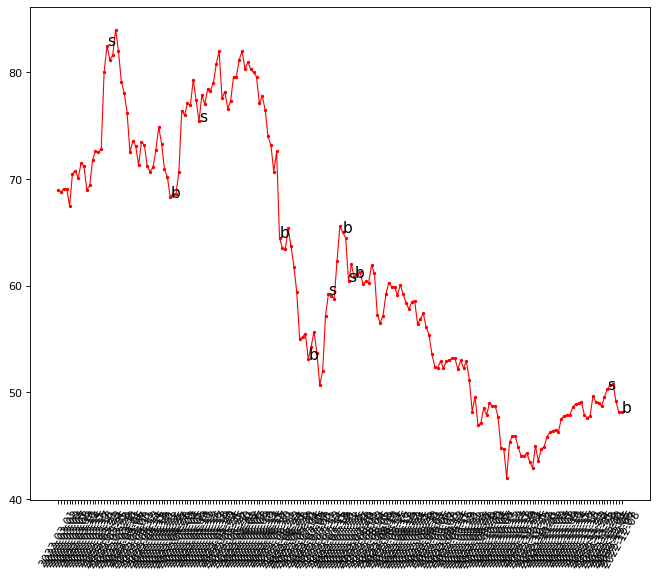

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plot
import time
mainid = '1030'
subid = '1033'
stockid='4952'
fig = plt.figure(figsize = (10, 8),dpi=80)
#,'8299',pd.to_datetime(datetime.date(2022,11,1))
start_date = datetime.date(2022, 3, 1)
end_date = datetime.date(2022, 12, 8)
single_date = end_date
#for single_date in daterange(start_date, end_date):
brokerdata = merge_sell_buy_data(mainid,subid,stockid,pd.to_datetime(single_date))
print(len(brokerdata))
#corr,cnt = get_correlation_value(brokerdata,'8299')
#計算正相關係數
corr,close,cnt = get_correlation_value(brokerdata,stockid,pd.to_datetime(single_date))

arr1 = close[stockid]
arr2 = close['bkdata']
a = np.array(arr2).reshape(-1,1)
b = arr1
reg = LinearRegression().fit(a,b)
b_pred = reg.predict(a)
#print(b_pred)'
close['pred'] = b_pred
#plot.plot(close['pred'])
#close.to_csv('psotck1.csv')
#plot.plot(close['8299'])
s1 = close[stockid]
#s1.reset_index(drop=True,inplace=True)
s2 = s1[s1 != 0]
#plot.plot(s2)

#condition1
close['bs'] = 0
pshift =  close['pred'].shift(1)
close['p_shift_diff'] =  close['pred']  - pshift
close['p_shift_diff'].fillna(0,inplace=True)
#close['p_shift_diff'] = close['p_shift_diff'].astype(np.int8)
s= (close['p_shift_diff'] != 0)
hold = pd.DataFrame(np.nan, index=close.index, columns=['t'])
hold[s] = 1
hold.fillna(0,inplace=True)
close['p_shift_diff']  = hold
close['p_shift_diff'] = close['p_shift_diff'].astype(np.int8)
close.head(2)
#condition2
close['p_stk_diff'] = close['pred'] -  close[stockid]
close['hold'] = np.nan
#close['trans_price'] = 0
close.head(5)

close = case2_trans(close,stockid)
#close['hold'].ffill(inplace= True)
#close['hold_price'].ffill(inplace= True)
close.fillna(0,inplace=True)
close.head(30)
close.to_csv('phold.csv')
colname = 'case2profit'
close[colname] = 0
close = caclprofit(colname,'trans2','hold_price2',close)
close.to_csv(f"phold_{single_date}_test.csv")    
s1 = close[[stockid,'bs','trans2','hold_price2']]

#bs_chart(s1,stockid)
bs_chart(s1,stockid,fig,'trans2')
time.sleep(0.3)

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plot
import time
def buildbschar(mainid,subid,stockid,single_date,fig):
    #for single_date in daterange(start_date, end_date):
    brokerdata = merge_sell_buy_data(mainid,subid,stockid,pd.to_datetime(single_date))
    #print(len(brokerdata))
    #corr,cnt = get_correlation_value(brokerdata,'8299')
    #計算正相關係數
    corr,close,cnt = get_correlation_value(brokerdata,stockid,pd.to_datetime(single_date))

    arr1 = close[stockid]
    arr2 = close['bkdata']
    a = np.array(arr2).reshape(-1,1)
    b = arr1
    reg = LinearRegression().fit(a,b)
    b_pred = reg.predict(a)
    #print(b_pred)
    #return b_pred
    return b_pred[len(b_pred)-1]
 


mainid = '7750'
subid = '7750'
stockid='8299'
#,'8299',pd.to_datetime(datetime.date(2022,11,1))
fig = plt.figure(figsize = (10, 8),dpi=80)

start_date = datetime.date(2023, 2, 21)
pred = buildbschar(mainid,subid,stockid,start_date,fig)
#pred

#ss = b_pred[len(b_pred)-1]
#print(ss)
close['pred'][pd.to_datetime(start_date)] = pred
#print(close['pred'][pd.to_datetime(start_date)])
close.head(30)

In [66]:


mainid = '7750'
subid = '7750'
stockid= '8299'
data = Data()
s89 = data.get("收盤價")
close = pd.DataFrame(s89)
close = close[stockid]
close = pd.DataFrame(close)
close['pred']=0.0



brokerdata =  merge_sell_buy_data(mainid,subid,stockid,datetime.datetime.now().date())
corr,close1,cnt = get_correlation_value(brokerdata,stockid,datetime.datetime.now().date())

close['bd'] = brokerdata['差額']
close['bd'].fillna(0,inplace=True)
close['bkdata'] = close1['bkdata']


#,'8299',pd.to_datetime(datetime.date(2022,11,1))
fig = plt.figure(figsize = (10, 8),dpi=80)
start_date = datetime.date(2023, 2, 15)
end_date = datetime.date(2023, 2, 22)
for single_date in daterange(start_date, end_date):
    #start_date = datetime.date(2022, 3, 30)
    print(single_date)
    pred = buildbschar(mainid,subid,stockid,single_date,fig)
    #print(pred)
    close['pred'][single_date] = pred


2023-02-15
2023-02-16
2023-02-17
2023-02-18
2023-02-19
2023-02-20
2023-02-21


<Figure size 800x640 with 0 Axes>

In [59]:
close

,8299,pred,bd,bkdata
date,,,,
2022-03-01,517.0,0.000000,0,0.0
2022-03-02,520.0,0.000000,0,0.0
2022-03-03,528.0,0.000000,24,24.0
2022-03-04,513.0,0.000000,0,24.0
2022-03-07,487.5,0.000000,0,24.0
...,...,...,...,...
2023-02-15,361.5,365.028284,0,-8.0
2023-02-16,364.5,365.025700,0,-8.0
2023-02-17,368.0,365.040176,0,-8.0


In [ ]:
mainid = '7750'
subid = '7750'
stockid='8299'
ss =  merge_sell_buy_data(mainid,subid,stockid,datetime.date(2023, 2, 20))


In [40]:
#close['bd'] = brokerdata['差額']
close['bd'].fillna(0,inplace=True)
close.to_csv('phold.csv')


-1.5099999999999998


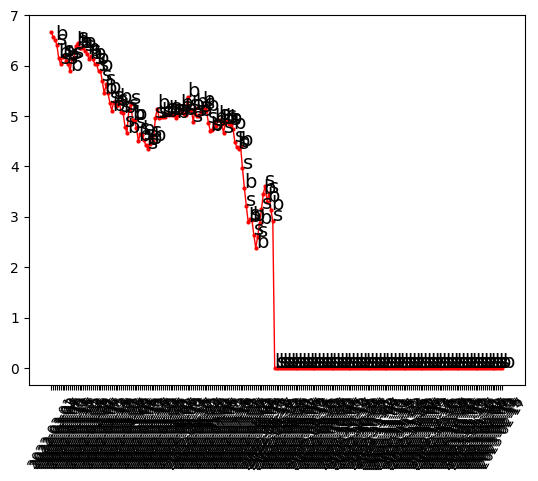

In [43]:
#print(b_pred)'
#close['pred'] = b_pred
#plot.plot(close['pred'])
close.to_csv('psotck1.csv')
#plot.plot(close['8299'])
s1 = close[stockid]
#s1.reset_index(drop=True,inplace=True)
s2 = s1[s1 != 0]
#plot.plot(s2)

#condition1
close['bs'] = 0
pshift =  close['pred'].shift(1)
close['p_shift_diff'] =  close['pred']  - pshift
close['p_shift_diff'].fillna(0,inplace=True)
#close['p_shift_diff'] = close['p_shift_diff'].astype(np.int8)
s= (close['p_shift_diff'] != 0)
hold = pd.DataFrame(np.nan, index=close.index, columns=['t'])
hold[s] = 1
hold.fillna(0,inplace=True)
close['p_shift_diff']  = hold
close['p_shift_diff'] = close['p_shift_diff'].astype(np.int8)
close.head(2)
#condition2
close['p_stk_diff'] = close['pred'] -  close[stockid]
close['hold'] = np.nan
#close['trans_price'] = 0
close.head(5)

close = case1_trans(close,stockid)
#close['hold'].ffill(inplace= True)
#close['hold_price'].ffill(inplace= True)
close.fillna(0,inplace=True)
close.head(30)
close.to_csv('phold.csv')
colname = 'case1profit'
close[colname] = 0
close = caclprofit(colname,'trans','hold_price',close)
close.to_csv('phold.csv')    
s1 = close[[stockid,'bs','trans','hold_price']]
bs_chart(s1,stockid,fig,'trans')
time.sleep(0.3)

-1


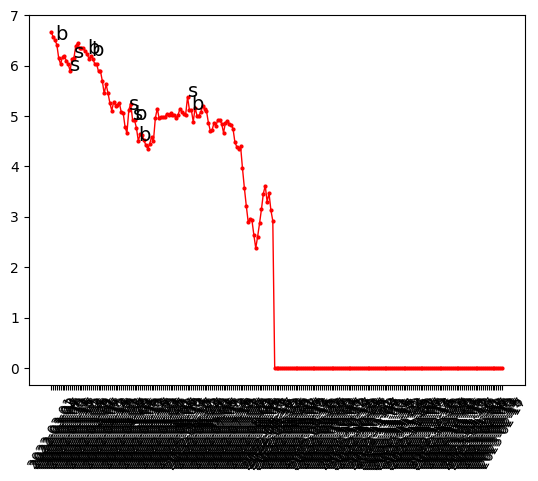

In [44]:

close = case2_trans(close,stockid)
#close['hold'].ffill(inplace= True)
#close['hold_price'].ffill(inplace= True)
close.fillna(0,inplace=True)
close.head(30)
close.to_csv('phold.csv')
colname = 'case2profit'
close[colname] = 0
close = caclprofit(colname,'trans2','hold_price2',close)
close.to_csv('phold.csv')    
s1 = close[[stockid,'bs','trans2','hold_price2']]
bs_chart(s1,stockid,fig,'trans2')
time.sleep(0.3)